Comparing with SMC-ABC

In [1]:
%pip install pyabc numpy scipy matplotlib

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 1.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.1 MB/s  0:00:00 eta 0:00:01
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)
Using cached smmap-5.0.3-py3-none-any.whl (24 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.manyl

In [16]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import pyabc
import matplotlib.pyplot as plt
from pyabc.visualization import plot_kde_matrix, plot_epsilons
from pyabc.sampler import SingleCoreSampler


Successfully loaded 27 data points.


ABC.History INFO: Start <ABCSMC id=1, start_time=2026-07-13 21:11:46>
ABC INFO: Calibration sample t = -1.


Starting SMC-ABC runs...


ABC INFO: t: 0, eps: 1.40589916e+04.
ABC INFO: Accepted: 500 / 946 = 5.2854e-01, ESS: 5.0000e+02.
ABC INFO: t: 1, eps: 3.02811305e+03.
ABC INFO: Accepted: 500 / 1069 = 4.6773e-01, ESS: 4.0031e+02.
ABC INFO: t: 2, eps: 5.83327622e+02.
ABC INFO: Accepted: 500 / 1198 = 4.1736e-01, ESS: 4.4448e+02.
ABC INFO: t: 3, eps: 1.16197115e+02.
ABC INFO: Accepted: 500 / 1252 = 3.9936e-01, ESS: 4.1110e+02.
ABC INFO: t: 4, eps: 1.53955364e+01.
ABC INFO: Accepted: 500 / 1366 = 3.6603e-01, ESS: 4.5691e+02.
ABC INFO: t: 5, eps: 4.99991880e+00.
ABC INFO: Accepted: 500 / 1095 = 4.5662e-01, ESS: 4.1864e+02.
ABC INFO: t: 6, eps: 2.51719051e+00.
ABC INFO: Accepted: 500 / 1156 = 4.3253e-01, ESS: 4.7814e+02.
ABC INFO: t: 7, eps: 1.57593371e+00.
ABC INFO: Accepted: 500 / 1059 = 4.7214e-01, ESS: 4.7678e+02.
ABC INFO: Stop: Minimum epsilon.
ABC.History INFO: Done <ABCSMC id=1, duration=0:00:18.477516, end_time=2026-07-13 21:12:04>


Inference complete.


ValueError: x and y must have same first dimension, but have shapes (27,) and (100,)

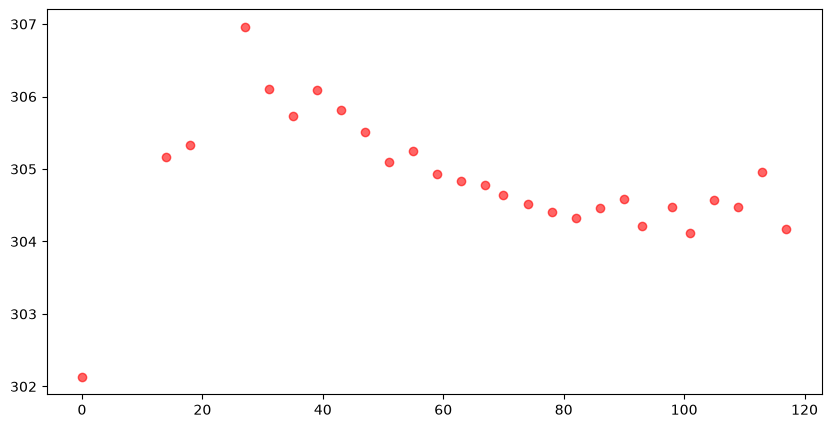

In [21]:
# ==========================================
# 1. Real Data Loading
# ==========================================
# Load your collected sensor data here. 
# We assume a CSV file named 'sensor_data.csv' with 'time' and 'temperature' columns.
file_path = './data/sequence_2/sequence_2_timeseries.csv'

try:
    df_data = pd.read_csv(file_path)
    time_steps = df_data['relative_time_sec'].values
    sensor_data = df_data['max_temperature_kelvin'].values
    print(f"Successfully loaded {len(time_steps)} data points.")
except FileNotFoundError:
    print(f"Warning: '{file_path}' not found. Generating a dummy dataset so the script can run.")

# Set the initial temperature to the very first sensor reading
T0 = sensor_data[0]

def newtons_cooling(k, T_env, t, T_initial):
    return T_env + (T_initial - T_env) * np.exp(-k * t)

# Package the real observations for pyabc
observation = {"temperature_curve": sensor_data}
# ==========================================
# 2. SMC-ABC Configuration
# ==========================================
def model(params):
    simulated_curve = newtons_cooling(params["k"], params["T_env"], time_steps, T0)
    return {"temperature_curve": simulated_curve}

prior = pyabc.Distribution(
    k=pyabc.RV("uniform", 0.001, 0.099),
    T_env=pyabc.RV("uniform", 300.0, 310.0)
)

#def distance(simulated, observed):
#    return np.linalg.norm(simulated["temperature_curve"] - observed["temperature_curve"])

def distance(simulated, observed):
    # FIXED: Swapped L2 Norm for Mean Squared Error (MSE). 
    # MSE is independent of the number of time steps and much more stable against noise.
    return np.mean((simulated["temperature_curve"] - observed["temperature_curve"])**2)

# ==========================================
# 3. Execution (Fixed for Jupyter)
# ==========================================
# This is the line where we initialize ABCSMC and add the SingleCoreSampler
abc = pyabc.ABCSMC(
    model, 
    prior, 
    distance, 
    population_size=500,
    sampler=SingleCoreSampler() # <--- Fixes the PicklingError
)

# Clean up the database file if it exists so you can re-run the notebook cell safely
db_file = "thermal_decay_smc.db"
if os.path.exists(db_file):
    os.remove(db_file)
    
db_path = "sqlite:///" + os.path.join(os.getcwd(), db_file)
abc.new(db_path, observation)

print("Starting SMC-ABC runs...")
history = abc.run(minimum_epsilon=2.0, max_nr_populations=12)
print("Inference complete.")

# New Visualization Section
# ==========================================
# 4. Visualization (Three Plots)
# ==========================================
# Extract the DataFrame (df) and weights (w) for the final generation
df, w = history.get_distribution(m=0, t=history.max_t)

# --- Plot 1: Model Fit (Posterior Predictive Check) ---
plt.figure(figsize=(10, 5))
plt.scatter(time_steps, sensor_data, color='red', alpha=0.6, label='Noisy Sensor Data', zorder=2)
plt.plot(time_steps, clean_data, color='black', linewidth=2, label='True Cooling Curve', zorder=3)

# Plot a sample of accepted curves from the final posterior to show the distribution
sample_size = min(100, len(df))
for i in range(sample_size):
    k_samp = df.iloc[i]['k']
    T_env_samp = df.iloc[i]['T_env']
    sim_curve = newtons_cooling(k_samp, T_env_samp, time_steps, T0)
    label = 'Posterior Predictive Samples' if i == 0 else None
    plt.plot(time_steps, sim_curve, color='blue', alpha=0.05, zorder=1, label=label)

plt.title('Model Fit: Sensor Data vs. Posterior Predictive Samples')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Plot 2: Epsilon Convergence ---
fig, ax = plt.subplots(figsize=(10, 3))
plot_epsilons(history, ax=ax)
plt.title('Algorithm Convergence: Tolerance (Epsilon) Decay Over Generations')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Plot 3: Parameter Posteriors (Corner Plot) ---
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plot_kde_matrix(
    df, w, 
    limits={"k": (0.001, 0.1), "T_env": (15, 40)},
    refval={"k": true_k, "T_env": true_T_env} 
)
plt.suptitle("Posterior Parameter Distributions (k and T_env)", y=1.02)
plt.show()